In [ ]:
import os
import pathlib
import random
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import requests
import glob
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten
from tensorflow.keras.utils import image_dataset_from_directory
from matplotlib.ticker import MultipleLocator,FormatStrFormatter
from dataclasses import dataclass
from zipfile import ZipFile
from urllib.request import urlretrieve

In [ ]:
SEED_VALUE=68
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

In [ ]:
def download_dataset(url,save_path):
  print('Downloding dataset...')
  urlretrieve(url,save_path)
  try:
    with ZipFile(save_path) as z:
      z.extractall(os.path.split(save_path)[0])
    print('Okay, downloaded and unzipped')
  except Exception as e:
    print('Sorry, exception: ',e)


In [ ]:
URL= r"https://www.dropbox.com/s/uzgh5g2bnz40o13/dataset_traffic_signs_40_samples_per_class.zip?dl=1"

In [ ]:
URL = r"https://www.dropbox.com/s/uzgh5g2bnz40o13/dataset_traffic_signs_40_samples_per_class.zip?dl=1"

dataset_path   = os.path.join(os.getcwd(), "dataset_traffic_signs_40_samples_per_class")
asset_zip_path = os.path.join(os.getcwd(), "dataset_traffic_signs_40_samples_per_class.zip")

# Download if assest ZIP does not exists.
if not os.path.exists(asset_zip_path):
    download_dataset(URL, asset_zip_path)

Downloding dataset...
Okay, downloaded and unzipped


In [ ]:
@dataclass(frozen=True)
class DatasetConfig:
  NUM_CLASSES: int = 43
  IMG_HEIGHT: int = 224
  IMG_WIDTH: int = 224
  CHANNELS: int = 3

  DATA_ROOT_TRAIN: str= os.path.join(dataset_path,'Train')
  DATA_ROOT_VALID: str= os.path.join(dataset_path,'Valid')
  DATA_ROOT_TEST:  str = os.path.join(dataset_path, 'Test')
  DATA_TEST_GT:    str = os.path.join(dataset_path,'Test.csv')
@dataclass(frozen=True)
class TrainingConfig:
  BATCH_SIZE: int = 32
  EPOCHS: int = 101
  LEARNING_RATE: float = 0.0001
  DROPOUT: float = 0.6
  LAYERS_FINE_TUNE: int = 8


In [ ]:
train_dataset = image_dataset_from_directory(directory=DatasetConfig.DATA_ROOT_TRAIN,
                                             batch_size=TrainingConfig.BATCH_SIZE,
                                             shuffle=True,
                                             seed=SEED_VALUE,
                                             label_mode='int',
                                             image_size=(DatasetConfig.IMG_HEIGHT,DatasetConfig.IMG_WIDTH),


                                             )
validation_dataset = image_dataset_from_directory(
    directory=DatasetConfig.DATA_ROOT_VALID,
    batch_size=TrainingConfig.BATCH_SIZE,
    shuffle=True,
    seed=SEED_VALUE,
    label_mode='int',
    image_size=(DatasetConfig.IMG_HEIGHT,DatasetConfig.IMG_WIDTH)

)


Found 1204 files belonging to 43 classes.
Found 516 files belonging to 43 classes.


In [ ]:
train_dataset.class_names

['0',
 '1',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '2',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '3',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '4',
 '40',
 '41',
 '42',
 '5',
 '6',
 '7',
 '8',
 '9']

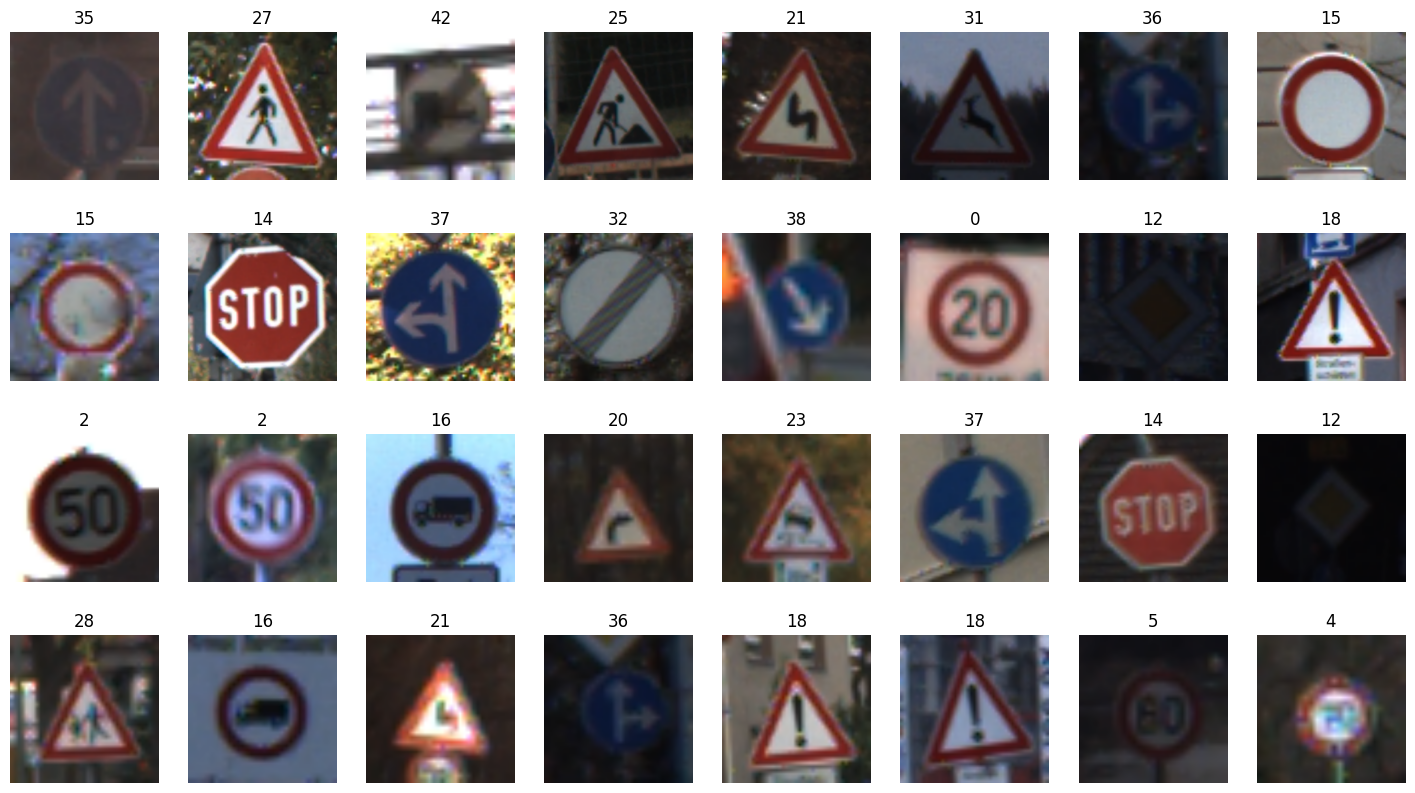

In [ ]:
class_name= train_dataset.class_names
plt.figure(figsize=(18,10))
n_rows=4
n_cols=8
for image_batch,labels_batch in train_dataset.take(1):
  for i in range(n_rows*n_cols):
    plt.subplot(n_rows,n_cols,i+1)
    plt.imshow(image_batch[i].numpy().astype('uint8'))
    truth_idx=labels_batch[i].numpy()
    plt.title(class_name[truth_idx])
    plt.axis(False)


In [ ]:
import pandas as pd
input_file=DatasetConfig.DATA_TEST_GT

dataset = pd.read_csv(input_file)
df = pd.DataFrame(dataset)
cols = [6]
df=df[df.columns[cols]]
ground_truth_ids = df['ClassId'].values.tolist()
print('Total number of Test labels: ',len(ground_truth_ids))
print(ground_truth_ids[:10])

Total number of Test labels:  12630
[16, 1, 38, 33, 11, 38, 18, 12, 25, 35]


In [ ]:
class_names_int = list(map(int,train_dataset.class_names))

gtid_2_cnidx = dict(zip(class_names_int,range(0,DatasetConfig.NUM_CLASSES)))

gtid_2_cnidx.items()

dict_items([(0, 0), (1, 1), (10, 2), (11, 3), (12, 4), (13, 5), (14, 6), (15, 7), (16, 8), (17, 9), (18, 10), (19, 11), (2, 12), (20, 13), (21, 14), (22, 15), (23, 16), (24, 17), (25, 18), (26, 19), (27, 20), (28, 21), (29, 22), (3, 23), (30, 24), (31, 25), (32, 26), (33, 27), (34, 28), (35, 29), (36, 30), (37, 31), (38, 32), (39, 33), (4, 34), (40, 35), (41, 36), (42, 37), (5, 38), (6, 39), (7, 40), (8, 41), (9, 42)])

In [20]:
label_ids=[]
for idx in range(len(ground_truth_ids)):
  label_ids.append(gtid_2_cnidx[ground_truth_ids[idx]])

print('Original ground truth class IDs: ',ground_truth_ids[:10])
print('New mapping required: ', label_ids[:10])
print('')
print('Train/Valid dataset class names: ',train_dataset.class_names)

Original ground truth class IDs:  [16, 1, 38, 33, 11, 38, 18, 12, 25, 35]
New mapping required:  [8, 1, 32, 27, 3, 32, 10, 4, 18, 29]

Train/Valid dataset class names:  ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


In [22]:
img_paths= sorted(glob.glob(os.path.join(DatasetConfig.DATA_ROOT_TEST+os.sep+'*.png')))
print(len(img_paths))
print('')
img_paths[:5]

12630



['/content/dataset_traffic_signs_40_samples_per_class/Test/00000.png',
 '/content/dataset_traffic_signs_40_samples_per_class/Test/00001.png',
 '/content/dataset_traffic_signs_40_samples_per_class/Test/00002.png',
 '/content/dataset_traffic_signs_40_samples_per_class/Test/00003.png',
 '/content/dataset_traffic_signs_40_samples_per_class/Test/00004.png']

In [23]:
test_dataset = tf.data.Dataset.from_tensor_slices((img_paths,label_ids))


In [28]:
def preprocess_img(img):
  img=tf.image.decode_png(img,channels=3)
  img=tf.image.resize(img,[DatasetConfig.IMG_HEIGHT,DatasetConfig.IMG_WIDTH])
  return img

In [29]:
def load_and_preprocess_img(path):
  img=tf.io.read_file(path)
  return preprocess_img(img)


In [30]:
def load_and_preprocess_from_path_label(path,label):
  return load_and_preprocess_img(path),label

In [31]:
test_dataset = test_dataset.map(load_and_preprocess_from_path_label)
test_dataset = test_dataset.batch(TrainingConfig.BATCH_SIZE)

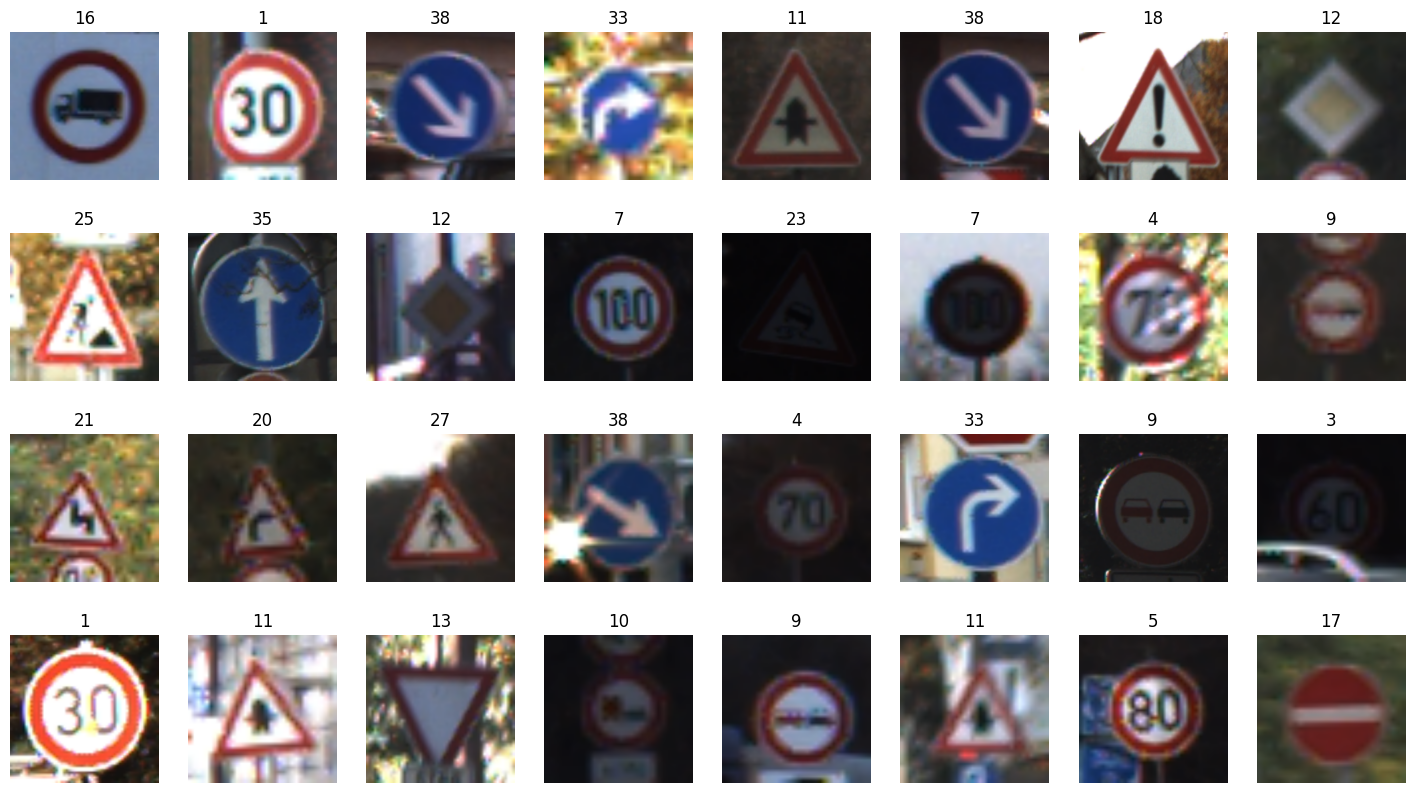

In [33]:
plt.figure(figsize=(18,10))
n_rows = 4
n_cols = 8
for img_batch, labels_batch in test_dataset.take(1):
  for i in range(n_rows*n_cols):
    plt.subplot(n_rows,n_cols,i+1)
    plt.imshow(img_batch[i].numpy().astype('uint8'))
    truth_idx = labels_batch[i].numpy()
    plt.title(class_name[truth_idx])
    plt.axis(False)

In [34]:
tf.keras.applications.vgg16.VGG16(include_top=True,
                                  weights='imagenet',
                                  input_shape=None,
                                  input_tensor=None,
                                  pooling=None,
                                  classes=1000,
                                  classifier_activation='softmax')

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


<Functional name=vgg16, built=True>

In [36]:
input_shape = (DatasetConfig.IMG_HEIGHT,DatasetConfig.IMG_WIDTH,DatasetConfig.CHANNELS)
print('Loading model with Imagenet weights')
vgg16_conv_base=tf.keras.applications.vgg16.VGG16(
    input_shape=input_shape,
    include_top=False,
    weights='imagenet',
)
vgg16_conv_base.summary()

Loading model with Imagenet weights
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
vgg16_conv_base.trainable = True
num_layers_fine_tune = TrainingConfig.LAYERS_FINE_TUNE
num_layers = len(vgg16_conv_base.layers)

for model_layer in vgg16_conv_base.layers[:num_layers-num_layers_fine_tune]:
  print('FREEZING LAYER: ',model_layer)
  model_layer.trainable = False

print()
print(f'Configured to fine tune the last {num_layers_fine_tune} convolution layers...')
print()
vgg16_conv_base.summary()

FREEZING LAYER:  <InputLayer name=input_layer_1, built=True>
FREEZING LAYER:  <Conv2D name=block1_conv1, built=True>
FREEZING LAYER:  <Conv2D name=block1_conv2, built=True>
FREEZING LAYER:  <MaxPooling2D name=block1_pool, built=True>
FREEZING LAYER:  <Conv2D name=block2_conv1, built=True>
FREEZING LAYER:  <Conv2D name=block2_conv2, built=True>
FREEZING LAYER:  <MaxPooling2D name=block2_pool, built=True>
FREEZING LAYER:  <Conv2D name=block3_conv1, built=True>
FREEZING LAYER:  <Conv2D name=block3_conv2, built=True>
FREEZING LAYER:  <Conv2D name=block3_conv3, built=True>
FREEZING LAYER:  <MaxPooling2D name=block3_pool, built=True>

Configured to fine tune the last 8 convolution layers...



Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 12,979,200 (49.51 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

In [38]:
inputs = tf.keras.Input(shape=input_shape)
x= tf.keras.applications.vgg16.preprocess_input(inputs)
x=vgg16_conv_base(x)
x=layers.Flatten()(x)
x=layers.Dense(128, activation='relu')(x)
x=layers.Dropout(TrainingConfig.DROPOUT)(x)

output= layers.Dense(DatasetConfig.NUM_CLASSES,activation='softmax')(x)
model_vgg16_finetune = keras.Model(inputs,output)
model_vgg16_finetune.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │  3,211,392 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 43)        │      5,547 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,931,627 (68.40 MB)

 Trainable params: 16,196,139 (61.78 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

In [41]:
model_vgg16_finetune.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=TrainingConfig.LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'],
)

In [42]:
training_results=model_vgg16_finetune.fit(train_dataset,epochs=TrainingConfig.EPOCHS,validation_data=validation_dataset)

Epoch 1/101
38/38 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.0182 - loss: 7.1608 - val_accuracy: 0.0233 - val_loss: 3.7572
Epoch 2/101
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 382ms/step - accuracy: 0.0373 - loss: 3.7527 - val_accuracy: 0.0426 - val_loss: 3.7279
Epoch 3/101
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 397ms/step - accuracy: 0.0431 - loss: 3.7266 - val_accuracy: 0.0543 - val_loss: 3.6862
Epoch 4/101
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 393ms/step - accuracy: 0.0570 - loss: 3.6690 - val_accuracy: 0.0775 - val_loss: 3.6076
Epoch 5/101
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 384ms/step - accuracy: 0.0720 - loss: 3.5833 - val_accuracy: 0.0659 - val_loss: 3.5302
Epoch 6/101
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 376ms/step - accuracy: 0.0823 - loss: 3.5157 - val_accuracy: 0.0950 - val_loss: 3.4044
Epoch 7/101
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 374ms/step - accuracy: 0.1140 - loss: 3.3351 - val_accuracy: 0.1395 - val_loss: 3.2889
Epoch 8/101
38/38 ━━━━━━━━━━━━━━━━━━━━ 17s 437ms/step - accuracy: 0.1301 - loss: 3.2046 - val

In [43]:
def plot_results(metrics,ylabel=None,ylim=None,metric_name=None,color=None):
  fig,ax=plt.subplots(figsize=(15,4))
  if not(isinstance(metrics,list) or isinstance(metrics,tuple)):
    metrics=[metrics,]
    metric_name=[metric_name,]
  for idx,metric in enumerate(metrics):
    ax.plot(metric,color=color[idx])
  plt.xlabel("EPOCH")
  plt.ylabel(ylabel)
  plt.xlim([0,TrainingConfig.EPOCHS-1])
  plt.ylim(ylim)
  ax.xaxis.set_major_locator(MultipleLocator(5))
  ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
  ax.xaxis.set_minor_locator(MultipleLocator(1))
  plt.grid(True)
  plt.legend(metric_name)
  plt.show()

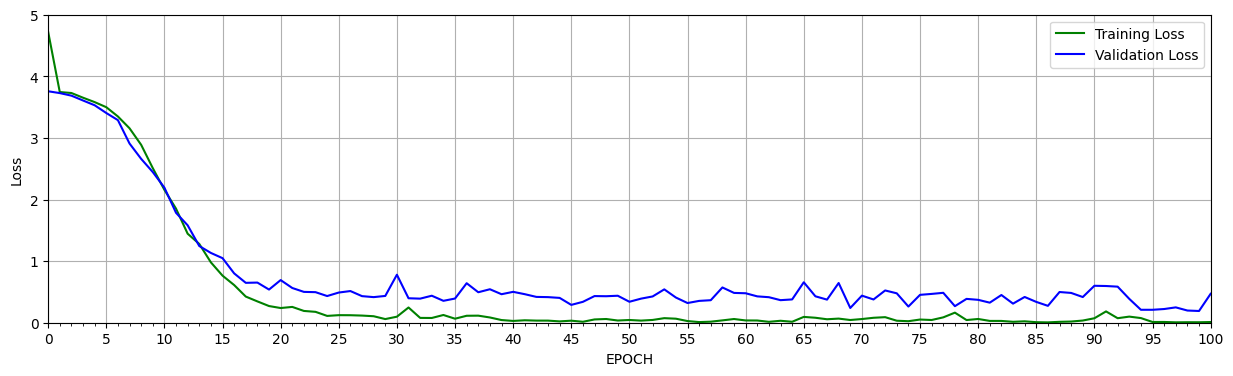

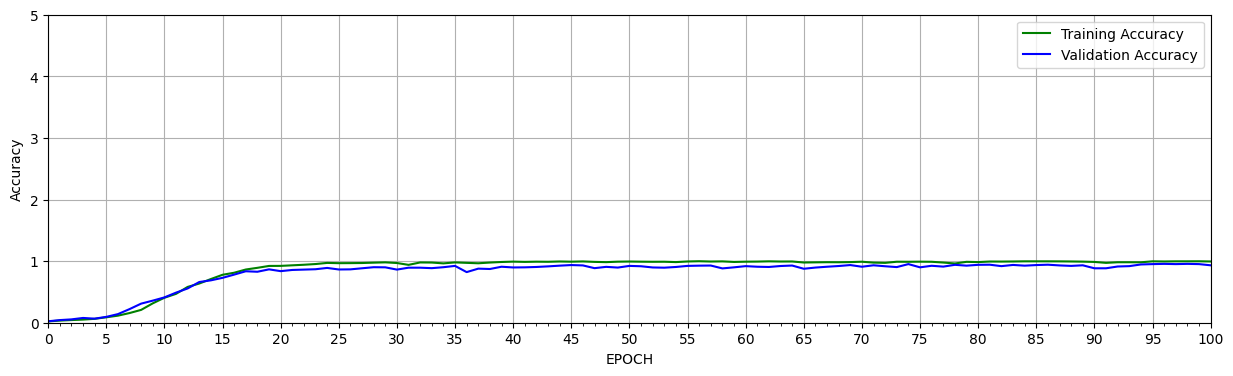

In [51]:
train_loss = training_results.history['loss']
train_acc = training_results.history['accuracy']
valid_loss = training_results.history['val_loss']
valid_acc = training_results.history['val_accuracy']
plot_results(
    [train_loss,valid_loss],
    ylabel='Loss',
    ylim=[0.0,5.0],
    metric_name=['Training Loss','Validation Loss'],
    color=['green','blue']
)
plot_results(
    [train_acc,valid_acc],
    ylabel='Accuracy',
    ylim=[0,5],
    metric_name=['Training Accuracy','Validation Accuracy'],
    color=['green','blue']
)

In [52]:
print(f'Model valid accuracy: {model_vgg16_finetune.evaluate(validation_dataset)[1]*100.:.3f}')

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.9320 - loss: 0.5695
Model valid accuracy: 93.217


In [45]:
print(f'Model test accuracy: {model_vgg16_finetune.evaluate(test_dataset)[1]*100.:.3f}')

395/395 ━━━━━━━━━━━━━━━━━━━━ 92s 233ms/step - accuracy: 0.9344 - loss: 0.4659
Model test accuracy: 93.357


In [53]:
def display_predictions(dataset, model, class_names):

    plt.figure(figsize=(20, 20))
    num_rows = 8
    num_cols = 8
    jdx = 0

    # Evaluate two batches.
    for image_batch, labels_batch in dataset.take(2):
        print(image_batch.shape)

        # Predictions for the current batch.
        predictions = model.predict(image_batch)

        # Loop over all the images in the current batch.
        for idx in range(len(labels_batch)):
            pred_idx = tf.argmax(predictions[idx]).numpy()
            truth_idx = labels_batch[idx].numpy()

            # Set the title color based on the prediction.
            if pred_idx == truth_idx:
                color = "g"
            else:
                color = "r"

            jdx += 1

            if jdx > num_rows * num_cols:
                # Break from the loops if the maximum number of images have been plotted
                break

            ax = plt.subplot(num_rows, num_cols, jdx)
            title = str(class_names[truth_idx]) + " : " + str(class_names[pred_idx])

            title_obj = plt.title(title)
            plt.setp(title_obj, color=color)
            plt.axis("off")
            plt.imshow(image_batch[idx].numpy().astype("uint8"))
    return

In [54]:
display_predictions(validation_dataset, model_vgg16_finetune, class_name)

Output hidden; open in https://colab.research.google.com to view.

In [55]:
display_predictions(test_dataset, model_vgg16_finetune, class_name)

Output hidden; open in https://colab.research.google.com to view.